In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
from tensorflow.keras.optimizers import Adam
import keras
from keras.models import Sequential, Model
from keras.layers import *
from keras.utils import Sequence
from keras.layers import Conv2D, MaxPooling2D
from qkeras import *

from keras.utils import Sequence
from keras.callbacks import CSVLogger
from keras.callbacks import EarlyStopping

import os
import random
from datetime import datetime
import time

import matplotlib.pyplot as plt

pi = 3.14159265359

maxval=1e9
minval=1e-9

2025-05-26 18:56:18.284240: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-26 18:56:18.284323: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-26 18:56:18.285907: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-26 18:56:18.294067: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-26 18:56:22.019498: W tensorflow/compiler/tf2

In [2]:
os.chdir('SmartPix/data_generator')
!pwd

/home/das214/SmartPix/data_generator


In [3]:
#from dataprep import *
from OptimizedDataGeneratorNew import OptimizedDataGenerator
from loss import *
from models import *

In [4]:
dataset_base_dir = "/depot/cms/users/das214/datasets/dataset_2s/dataset_2s_50x12P5_parquets/"
tfrecords_base_dir = os.path.join(dataset_base_dir, "TFR_files", "2t")

dataset_base_dir = os.path.join(dataset_base_dir, "parquets")
tfrecords_dir_train = os.path.join(tfrecords_base_dir, "TFR_train")
tfrecords_dir_val   = os.path.join(tfrecords_base_dir, "TFR_val")

batch_size = 5000
val_batch_size = 5000
train_file_size = 75
val_file_size = 25

In [5]:
import os
import gc
import math
import glob
import random
import logging
import datetime
import numpy as np
import pandas as pd

from typing import Union, List, Tuple
from concurrent.futures import ProcessPoolExecutor, ThreadPoolExecutor, as_completed

from tqdm import tqdm
import tensorflow as tf
from qkeras import quantized_bits


def split_df_to_X_y_df(df: pd.DataFrame,
                       labels_list: List[str],
                       recon_cols: List[int]) -> Tuple[pd.DataFrame, pd.DataFrame]:

    X_df = df[recon_cols].copy()
    y_df = df[labels_list].copy()

    return X_df, y_df


In [8]:
start_time = time.time()
validation_generator = OptimizedDataGenerator(
    dataset_base_dir = dataset_base_dir,
    file_type = "parquet",
    data_format = "3D",
    batch_size = val_batch_size,
    file_count = val_file_size,
    to_standardize= True,
    include_y_local= False,
    labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
    input_shape = (2,13,21), # (20,13,21),
    transpose = (0,2,3,1),
    shuffle = False, 
    files_from_end=True,

    tfrecords_dir = tfrecords_dir_val,
    use_time_stamps = [0,19],
    max_workers = 2
)

print("--- Validation generator %s seconds ---" % (time.time() - start_time))

# training generator
start_time = time.time()
training_generator = OptimizedDataGenerator(
    dataset_base_dir = dataset_base_dir,
    file_type = "parquet",
    data_format = "3D",
    batch_size = batch_size,
    file_count = train_file_size,
    to_standardize= True,
    include_y_local= False,
    labels_list = ['x-midplane','y-midplane','cotAlpha','cotBeta'],
    input_shape = (2,13,21), # (20,13,21),
    transpose = (0,2,3,1),
    shuffle = False, # True 

    tfrecords_dir = tfrecords_dir_train,
    use_time_stamps = [0,19],
    max_workers = 2
)
print("--- Training generator %s seconds ---" % (time.time() - start_time))

Directory /depot/cms/users/das214/datasets/dataset_2s/dataset_2s_50x12P5_parquets/TFR_files/2t/TFR_val is removed...


Saving batches as TFRecords: 100%|██████████| 101/101 [00:21<00:00,  4.80it/s]


--- Validation generator 29.59588074684143 seconds ---
Directory /depot/cms/users/das214/datasets/dataset_2s/dataset_2s_50x12P5_parquets/TFR_files/2t/TFR_train is removed...


Saving batches as TFRecords: 100%|██████████| 305/305 [00:53<00:00,  5.66it/s]


--- Training generator 78.32148456573486 seconds ---


In [149]:
TOL = 1e-6                      
SCALE = 1 / TOL                 

def load_and_transform_event(gen, file_id):
    df = pd.read_parquet(gen.files[file_id],
                         columns=gen.recon_cols + gen.labels_list)

    # split & NaN mask (same as generator)
    recon_df, y_df = split_df_to_X_y_df(df,
                        gen.labels_list,
                        gen.recon_cols)

    X = recon_df.values.reshape((-1, *gen.input_shape))
    X = X.transpose(gen.transpose)

    m = X != 0
    X[m] = (np.sign(X[m]) *
            np.log1p(np.abs(X[m])) / math.log(2) -
            gen.dataset_mean) / gen.dataset_std
    pos, neg = X > 0, X < 0
    X[pos] /= 1.7;  X[neg] /= 2.5

    y = y_df.values / np.array([75., 18.75, 8.0, 0.5])

    return X, y


def build_vec_index(gen):
    lbls, batches, events = [], [], []
    for b in tqdm(range(len(gen)), desc = "Building LUT"):
        _, yb = gen[b]
        arr = np.round(yb.numpy() * SCALE).astype("int64")
        # arr = yb.numpy()
        lbls.append(arr)
        batches.append(np.full(len(arr), b, "int32"))
        events.append(np.arange(len(arr), dtype="int32"))
    lbls   = np.vstack(lbls)               # shape (N, 4)
    batches = np.concatenate(batches)
    events  = np.concatenate(events)
    return lbls, batches, events           # all NumPy


In [ ]:
lbls,bs,es    = build_vec_index(training_generator)

In [138]:
# vector lookup (first match)
def vec_lookup(target_lab, lbls, batches, events):
    # force float32 match to mimic TF's dtype
    key = np.round(target_lab.astype("float32") * SCALE).astype("int64")
    hit = np.flatnonzero((lbls == key).all(1))
    if hit.size == 0:
        raise KeyError(f"label absent: {key/SCALE}")
    i = hit[0]
    b, e = int(batches[i]), int(events[i])
    print(f"Match Found: batch {b}, event {e}")
    return b, e

In [155]:
event_id = 0
file_id = 0

print("event_id:", event_id, "file_id:", file_id)

features_from_file, labels_from_file = load_and_transform_event(training_generator, file_id)
target_feat, target_lab = features_from_file[event_id], labels_from_file[event_id]

b, e          = vec_lookup(target_lab, lbls, bs, es)
labels_from_gen = training_generator[b][1].numpy()
print("Target label:", target_lab, "\nMatched label:", labels_from_gen[e])

event_id: 0 file_id: 0
Match Found: batch 0, event 0
Target label: [-0.86068334 -0.4470642   0.88435855  0.13003095] 
Matched label: [-0.8606833  -0.4470642   0.8843585   0.13003094]


In [156]:
event_id = 1
file_id = 0

print("event_id:", event_id, "file_id:", file_id)

features_from_file, labels_from_file = load_and_transform_event(training_generator, file_id)
target_feat, target_lab = features_from_file[event_id], labels_from_file[event_id]

b, e          = vec_lookup(target_lab, lbls, bs, es)
labels_from_gen = training_generator[b][1].numpy()
print("Target label:", target_lab, "\nMatched label:", labels_from_gen[e])

event_id: 1 file_id: 0


Match Found: batch 0, event 3
Target label: [0.9577637  0.63724839 0.70777618 0.09289231] 
Matched label: [0.9577637  0.6372484  0.7077762  0.09289231]


In [ ]:
event_id = 1
file_id = 1

print("event_id:", event_id, "file_id:", file_id)

features_from_file, labels_from_file = load_and_transform_event(training_generator, file_id)
target_feat, target_lab = features_from_file[event_id], labels_from_file[event_id]

b, e          = vec_lookup(target_lab, lbls, bs, es)
labels_from_gen = training_generator[b][1].numpy()
print("Target label:", target_lab, "\nMatched label:", labels_from_gen[e])

event_id: 1 file_id: 1


KeyError: 'label absent: [-0.233444 -0.772251  0.81905   0.027973]'

In [164]:
event_id = 5
file_id = 1

print("event_id:", event_id, "file_id:", file_id)

features_from_file, labels_from_file = load_and_transform_event(training_generator, file_id)
target_feat, target_lab = features_from_file[event_id], labels_from_file[event_id]

b, e          = vec_lookup(target_lab, lbls, bs, es)
labels_from_gen = training_generator[b][1].numpy()
print("Target label:", target_lab, "\nMatched label:", labels_from_gen[e])

event_id: 5 file_id: 1


KeyError: 'label absent: [ 0.824527  0.129664 -0.373856 -0.37702 ]'

In [166]:
for fi in tqdm(range(1, 75)):
    for ei in range(5000):
        try:
            features_from_file, labels_from_file = load_and_transform_event(training_generator, fi)
            target_feat, target_lab = features_from_file[ei], labels_from_file[ei]

            b, e = vec_lookup(target_lab, lbls, bs, es)

        except Exception:
            continue  # skip to next iteration if anything fails
        else:
            print(f"✅ Match found at file {fi}, event {ei}")
            print("Label:", target_lab)
            # break  # no error → break inner loop

    else:
        continue  # inner loop did NOT break → continue outer loop
    break  # inner loop broke → break outer loop


  0%|          | 0/74 [00:00<?, ?it/s]

Match Found: batch 272, event 2783
✅ Match found at file 1, event 4
Label: [ 0.50031438  0.0235228  -0.00701243  0.4879021 ]
Match Found: batch 283, event 518
✅ Match found at file 1, event 6
Label: [-0.67825886  0.89386771 -0.60907013 -0.19199174]
Match Found: batch 272, event 412
✅ Match found at file 1, event 21
Label: [0.47507142 0.47116316 0.99143261 0.46491851]
Match Found: batch 272, event 4212
✅ Match found at file 1, event 23
Label: [-0.01701605 -0.76782588 -0.45352126 -0.34701151]
Match Found: batch 250, event 1711
✅ Match found at file 1, event 24
Label: [0.57540143 0.67161861 0.35390621 0.20326436]
Match Found: batch 261, event 3753
✅ Match found at file 1, event 26
Label: [-0.85370751  0.19375802 -0.23253257 -0.3094362 ]
Match Found: batch 272, event 4276
✅ Match found at file 1, event 31
Label: [-0.54331588 -0.23127459  0.20669749 -0.2546061 ]
Match Found: batch 250, event 4626
✅ Match found at file 1, event 33
Label: [ 0.40004161  0.41743351 -0.49073381  0.32344563]
Matc

  0%|          | 0/74 [16:15<?, ?it/s]


KeyboardInterrupt: 


Original label: [-0.86068334 -0.4470642   0.88435855  0.13003095]


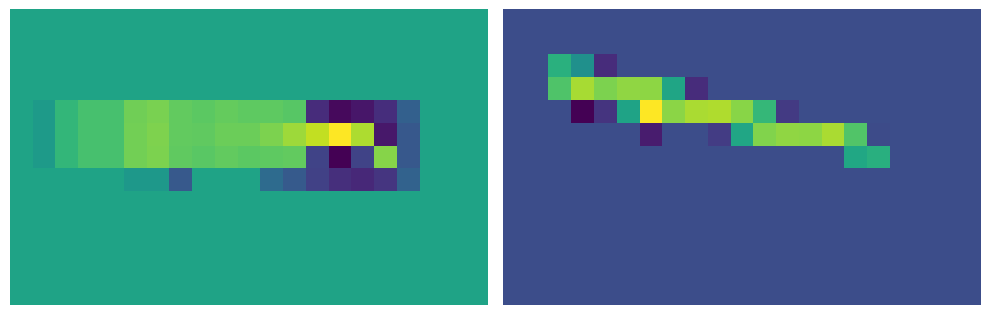


Matched label: [-0.8606833  -0.4470642   0.8843585   0.13003094]


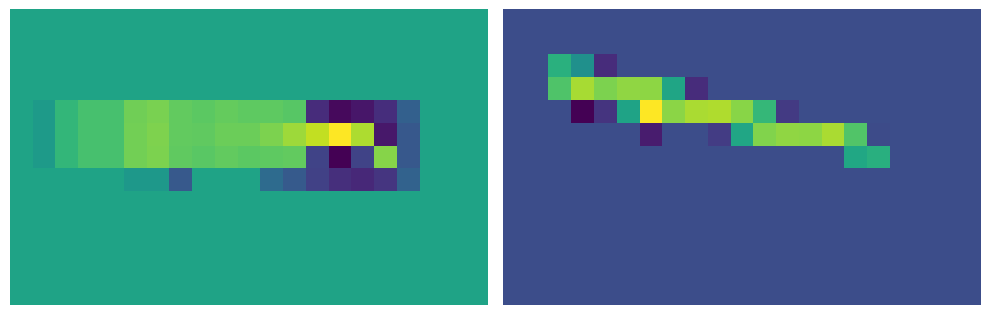

In [146]:
features_np, labels_np = training_generator[b]
features_np = features_np.numpy()
labels_np   = labels_np.numpy()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i in range(2):
    ax[i].imshow(target_feat[:, :, i])
    ax[i].axis('off')
print("\nOriginal label:", target_lab)
plt.tight_layout(); plt.show()

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i in range(2):
    ax[i].imshow(features_np[e, :, :, i])
    ax[i].axis('off')
print("\nMatched label:", labels_np[e])
plt.tight_layout(); plt.show()

In [ ]:

labels_np[0:4]

array([[-0.8606833 , -0.4470642 ,  0.8843585 ,  0.13003094],
       [-0.20211774, -0.28995904, -0.16732755,  0.03493707],
       [-0.15539297, -0.23210308, -0.36100653, -0.2008816 ],
       [ 0.9577637 ,  0.6372484 ,  0.7077762 ,  0.09289231]],
      dtype=float32)

In [23]:
model=CreateModel((13,21,2),n_filters=5,pool_size=3)
model.compile(
    optimizer=tf.keras.optimizers.Nadam(learning_rate=1e-3),
    loss=custom_loss
)

model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 13, 21, 2)]       0         
                                                                 
 q_separable_conv2d_1 (QSep  (None, 11, 19, 5)         33        
 arableConv2D)                                                   
                                                                 
 q_activation_5 (QActivatio  (None, 11, 19, 5)         0         
 n)                                                              
                                                                 
 q_conv2d_1 (QConv2D)        (None, 11, 19, 5)         30        
                                                                 
 q_activation_6 (QActivatio  (None, 11, 19, 5)         0         
 n)                                                              
                                                           

In [24]:
from datetime import datetime

fingerprint = '%08x' % random.randrange(16**8)
timestamp = datetime.now().strftime('%Y%m%d-%H%M%S')
os.makedirs("trained_models", exist_ok=True)
base_dir = f'./trained_models/model-{fingerprint}-checkpoints'
os.makedirs(base_dir, exist_ok=True)  
checkpoint_filepath = base_dir + '/weights.{epoch:02d}-t{loss:.2f}-v{val_loss:.2f}.hdf5'

In [25]:
print(fingerprint)

10ab44c3


In [26]:
from tensorflow.keras.callbacks import CSVLogger, EarlyStopping, ModelCheckpoint, Callback

early_stopping_patience = 50

class CustomModelCheckpoint(ModelCheckpoint):
    def on_epoch_end(self, epoch, logs=None):
        super().on_epoch_end(epoch, logs)
        checkpoints = [f for f in os.listdir(base_dir) if f.startswith('weights')]
        if len(checkpoints) > 1:
            checkpoints.sort()
            for checkpoint in checkpoints[:-1]:
                os.remove(os.path.join(base_dir, checkpoint))

es = EarlyStopping(patience=early_stopping_patience, restore_best_weights=True)

mcp = CustomModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=True,
    monitor='val_loss',
    save_best_only=True,
    save_freq='epoch',
    verbose=1
)

csv_logger = CSVLogger(f'{base_dir}/training_log.csv', append=True)

In [27]:
history = model.fit(
        x=training_generator,
        validation_data=validation_generator,
        callbacks=[es, mcp, csv_logger],
        epochs=1000,
        shuffle=False,
        verbose=1
    )

Epoch 1/1000
305/305 [==============================] - ETA: 0s - loss: 23348.1797
Epoch 1: val_loss improved from inf to 12409.19141, saving model to ./trained_models/model-10ab44c3-checkpoints/weights.01-t23348.18-v12409.19.hdf5
305/305 [==============================] - 30s 88ms/step - loss: 23348.1797 - val_loss: 12409.1914
Epoch 2/1000
305/305 [==============================] - ETA: 0s - loss: 11693.2109
Epoch 2: val_loss improved from 12409.19141 to 10884.20312, saving model to ./trained_models/model-10ab44c3-checkpoints/weights.02-t11693.21-v10884.20.hdf5
305/305 [==============================] - 26s 85ms/step - loss: 11693.2109 - val_loss: 10884.2031
Epoch 3/1000
305/305 [==============================] - ETA: 0s - loss: 10460.5381
Epoch 3: val_loss improved from 10884.20312 to 9958.90820, saving model to ./trained_models/model-10ab44c3-checkpoints/weights.03-t10460.54-v9958.91.hdf5
305/305 [==============================] - 26s 84ms/step - loss: 10460.5381 - val_loss: 9958.90

KeyboardInterrupt: 